# mapping

### qasmbench-medium

In [30]:
import pandas as pd
import os

directory = "/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ibm_sherbrooke/qasmbench-medium"
files = ["qpilot.csv", "cirq.csv", "qmap.csv", "pytket.csv", "eoh.csv", "funsearch.csv", "reevo.csv", "Randsample.csv", "mcts-ahd.csv", "sabre.csv", "partevo.csv"]
columns_to_mean = ["swap_count", "final_depth"]

summary_data = []

for file_name in files:
    file_path = os.path.join(directory, file_name)
    if os.path.exists(file_path):
        try:
            df = pd.read_csv(file_path)
            means = df[columns_to_mean].mean().to_dict()
            means['source_file'] = file_name
            summary_data.append(means)
        except Exception as e:
            print(f"Error processing {file_name}: {e}")
    else:
        print(f"File not found: {file_path}")

summary_df = pd.DataFrame(summary_data)
cols = ['source_file'] + columns_to_mean
summary_df = summary_df[cols]
print("\nPreview of the data:")
print(summary_df)


Preview of the data:
       source_file  swap_count  final_depth
0       qpilot.csv   99.842105   284.210526
1         cirq.csv  100.157895   306.631579
2         qmap.csv   92.052632   299.842105
3       pytket.csv  139.736842   308.263158
4          eoh.csv  105.157895   304.368421
5    funsearch.csv  103.263158   299.368421
6        reevo.csv  102.578947   298.315789
7   Randsample.csv  103.842105   298.894737
8     mcts-ahd.csv  106.473684   308.473684
9        sabre.csv   98.842105   291.947368
10     partevo.csv  106.052632   300.578947


In [31]:
import pandas as pd
import os

llm_path = "/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ibm_sherbrooke/qasmbench-medium/qpilot.csv"
try:
    df_llm = pd.read_csv(llm_path)
    llm_swaps = df_llm["swap_count"].mean()
    llm_depth = df_llm["final_depth"].mean()
except Exception as e:
    print(f"Error reading LLM file: {e}")
    exit()

baselines = {}


directory = "/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ibm_sherbrooke/qasmbench-medium"
files = ["cirq.csv", "qmap.csv", "pytket.csv", "eoh.csv", "funsearch.csv", "reevo.csv", "Randsample.csv", "mcts-ahd.csv", "sabre.csv", "partevo.csv"]

for file_name in files:
    file_path = os.path.join(directory, file_name)
    if os.path.exists(file_path):
        try:
            df = pd.read_csv(file_path)
            method_name = file_name.replace(".csv", "")
            baselines[method_name] = {
                "swaps": df["swap_count"].mean(),
                "depth": df["final_depth"].mean()
            }
        except Exception as e:
            print(f"Error processing {file_name}: {e}")
    else:
        print(f"File not found: {file_path}")

improvement_data = []

for method, metrics in baselines.items():
    base_swaps = metrics["swaps"]
    base_depth = metrics["depth"]
    
    swap_imp = ((base_swaps - llm_swaps) / base_swaps) * 100
    depth_imp = ((base_depth - llm_depth) / base_depth) * 100
    
    improvement_data.append({
        "Method": method,
        "Swap Improvement (%)": swap_imp,
        "Depth Improvement (%)": depth_imp
    })

if improvement_data:
    results_df = pd.DataFrame(improvement_data)
    print(results_df.to_string(index=False, float_format="%.2f"))    
    print(f"Average Swap Improvement:  {results_df['Swap Improvement (%)'].mean():.2f}%")
    print(f"Average Depth Improvement: {results_df['Depth Improvement (%)'].mean():.2f}%")
else:
    print("No baseline data was processed.")

    Method  Swap Improvement (%)  Depth Improvement (%)
      cirq                  0.32                   7.31
      qmap                 -8.46                   5.21
    pytket                 28.55                   7.80
       eoh                  5.06                   6.62
 funsearch                  3.31                   5.06
     reevo                  2.67                   4.73
Randsample                  3.85                   4.91
  mcts-ahd                  6.23                   7.87
     sabre                 -1.01                   2.65
   partevo                  5.86                   5.45
Average Swap Improvement:  4.64%
Average Depth Improvement: 5.76%


### qasmbench-large

In [27]:
import pandas as pd
import os

directory = "/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ibm_sherbrooke/qasmbench-large"
files = ["qpilot.csv", "cirq.csv", "qmap.csv", "pytket.csv", "eoh.csv", "funsearch.csv", "reevo.csv", "Randsample.csv", "mcts-ahd.csv", "hill_climb.csv", "sabre.csv", "partevo.csv"]
columns_to_mean = ["swap_count", "final_depth"]

summary_data = []

for file_name in files:
    file_path = os.path.join(directory, file_name)
    if os.path.exists(file_path):
        try:
            df = pd.read_csv(file_path)
            means = df[columns_to_mean].mean().to_dict()
            means['source_file'] = file_name
            summary_data.append(means)
        except Exception as e:
            print(f"Error processing {file_name}: {e}")
    else:
        print(f"File not found: {file_path}")

summary_df = pd.DataFrame(summary_data)
cols = ['source_file'] + columns_to_mean
summary_df = summary_df[cols]
print("\nPreview of the data:")
print(summary_df)


Preview of the data:
       source_file  swap_count  final_depth
0       qpilot.csv  489.272727   902.409091
1         cirq.csv  646.727273  1032.363636
2         qmap.csv  507.409091   925.818182
3       pytket.csv  587.954545  1028.772727
4          eoh.csv  519.954545   897.681818
5    funsearch.csv  521.818182   917.681818
6        reevo.csv  498.363636   922.181818
7   Randsample.csv  526.181818   922.090909
8     mcts-ahd.csv  521.545455   921.636364
9   hill_climb.csv  590.545455   996.500000
10       sabre.csv  577.772727  1066.909091
11     partevo.csv  525.636364   935.727273


In [28]:
import pandas as pd
import os

llm_path = "/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ibm_sherbrooke/qasmbench-large/qpilot.csv"
try:
    df_llm = pd.read_csv(llm_path)
    llm_swaps = df_llm["swap_count"].mean()
    llm_depth = df_llm["final_depth"].mean()
except Exception as e:
    print(f"Error reading LLM file: {e}")
    exit()

baselines = {}


directory = "/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ibm_sherbrooke/qasmbench-large"
files = ["cirq.csv", "qmap.csv", "pytket.csv", "eoh.csv", "funsearch.csv", "reevo.csv", "Randsample.csv", "mcts-ahd.csv", "hill_climb.csv", "sabre.csv", "partevo.csv"]

for file_name in files:
    file_path = os.path.join(directory, file_name)
    if os.path.exists(file_path):
        try:
            df = pd.read_csv(file_path)
            method_name = file_name.replace(".csv", "")
            baselines[method_name] = {
                "swaps": df["swap_count"].mean(),
                "depth": df["final_depth"].mean()
            }
        except Exception as e:
            print(f"Error processing {file_name}: {e}")
    else:
        print(f"File not found: {file_path}")

improvement_data = []

for method, metrics in baselines.items():
    base_swaps = metrics["swaps"]
    base_depth = metrics["depth"]
    
    swap_imp = ((base_swaps - llm_swaps) / base_swaps) * 100
    depth_imp = ((base_depth - llm_depth) / base_depth) * 100
    
    improvement_data.append({
        "Method": method,
        "Swap Improvement (%)": swap_imp,
        "Depth Improvement (%)": depth_imp
    })
    

if improvement_data:
    results_df = pd.DataFrame(improvement_data)
    print(results_df.to_string(index=False, float_format="%.2f"))    
    print(f"Average Swap Improvement:  {results_df['Swap Improvement (%)'].mean():.2f}%")
    print(f"Average Depth Improvement: {results_df['Depth Improvement (%)'].mean():.2f}%")
else:
    print("No baseline data was processed.")

    Method  Swap Improvement (%)  Depth Improvement (%)
      cirq                 24.35                  12.59
      qmap                  3.57                   2.53
    pytket                 16.78                  12.28
       eoh                  5.90                  -0.53
 funsearch                  6.24                   1.66
     reevo                  1.82                   2.14
Randsample                  7.01                   2.13
  mcts-ahd                  6.19                   2.09
hill_climb                 17.15                   9.44
     sabre                 15.32                  15.42
   partevo                  6.92                   3.56
Average Swap Improvement:  10.11%
Average Depth Improvement: 5.76%


### queko 16qbt

In [4]:
import pandas as pd
import os

directory = "/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ibm_sherbrooke/queko-bss-16qbt"
files = ["qpilot.csv", "cirq.csv", "qmap.csv", "pytket.csv", "eoh.csv", "funsearch.csv", "reevo.csv", "Randsample.csv", "mcts-ahd.csv", "hill_climb.csv", "sabre.csv", "partevo.csv"]
columns_to_mean = ["swap_count", "final_depth"]

summary_data = []

for file_name in files:
    file_path = os.path.join(directory, file_name)
    if os.path.exists(file_path):
        try:
            df = pd.read_csv(file_path)
            means = df[columns_to_mean].mean().to_dict()
            means['source_file'] = file_name
            summary_data.append(means)
        except Exception as e:
            print(f"Error processing {file_name}: {e}")
    else:
        print(f"File not found: {file_path}")

summary_df = pd.DataFrame(summary_data)
cols = ['source_file'] + columns_to_mean
summary_df = summary_df[cols]
print("\nPreview of the data:")
print(summary_df)


Preview of the data:
       source_file  swap_count  final_depth
0       qpilot.csv  572.344444   960.655556
1         cirq.csv  824.711111  1150.033333
2         qmap.csv  845.011111  1293.944444
3       pytket.csv  774.811111  1179.688889
4          eoh.csv  795.444444  1137.533333
5    funsearch.csv  793.777778  1314.900000
6        reevo.csv  617.166667  1076.633333
7   Randsample.csv  622.333333  1063.833333
8     mcts-ahd.csv  747.844444  1265.511111
9   hill_climb.csv  780.888889  1327.255556
10       sabre.csv  604.111111   981.522222
11     partevo.csv  686.677778  1174.700000


In [5]:
import pandas as pd
import os

llm_path = "/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ibm_sherbrooke/queko-bss-16qbt/qpilot.csv"
try:
    df_llm = pd.read_csv(llm_path)
    llm_swaps = df_llm["swap_count"].mean()
    llm_depth = df_llm["final_depth"].mean()
except Exception as e:
    print(f"Error reading LLM file: {e}")
    exit()

baselines = {}


directory = "/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ibm_sherbrooke/queko-bss-16qbt"
files = ["cirq.csv", "qmap.csv", "pytket.csv", "eoh.csv", "funsearch.csv", "reevo.csv", "Randsample.csv", "mcts-ahd.csv", "hill_climb.csv", "sabre.csv", "partevo.csv"]

for file_name in files:
    file_path = os.path.join(directory, file_name)
    if os.path.exists(file_path):
        try:
            df = pd.read_csv(file_path)
            method_name = file_name.replace(".csv", "")
            baselines[method_name] = {
                "swaps": df["swap_count"].mean(),
                "depth": df["final_depth"].mean()
            }
        except Exception as e:
            print(f"Error processing {file_name}: {e}")
    else:
        print(f"File not found: {file_path}")

improvement_data = []

for method, metrics in baselines.items():
    base_swaps = metrics["swaps"]
    base_depth = metrics["depth"]
    
    swap_imp = ((base_swaps - llm_swaps) / base_swaps) * 100
    depth_imp = ((base_depth - llm_depth) / base_depth) * 100
    
    improvement_data.append({
        "Method": method,
        "Swap Improvement (%)": swap_imp,
        "Depth Improvement (%)": depth_imp
    })

if improvement_data:
    results_df = pd.DataFrame(improvement_data)
    print(results_df.to_string(index=False, float_format="%.2f"))    
    print(f"Average Swap Improvement:  {results_df['Swap Improvement (%)'].mean():.2f}%")
    print(f"Average Depth Improvement: {results_df['Depth Improvement (%)'].mean():.2f}%")
else:
    print("No baseline data was processed.")

    Method  Swap Improvement (%)  Depth Improvement (%)
      cirq                 30.60                  16.47
      qmap                 32.27                  25.76
    pytket                 26.13                  18.57
       eoh                 28.05                  15.55
 funsearch                 27.90                  26.94
     reevo                  7.26                  10.77
Randsample                  8.03                   9.70
  mcts-ahd                 23.47                  24.09
hill_climb                 26.71                  27.62
     sabre                  5.26                   2.13
   partevo                 16.65                  18.22
Average Swap Improvement:  21.12%
Average Depth Improvement: 17.80%


### queko 54qbt

In [6]:
import pandas as pd
import os

directory = "/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ibm_sherbrooke/queko-bss-54qbt"
files = ["qpilot.csv", "cirq.csv", "qmap.csv", "pytket.csv", "eoh.csv", "funsearch.csv", "reevo.csv", "Randsample.csv", "mcts-ahd.csv", "hill_climb.csv", "sabre.csv", "partevo.csv"]
columns_to_mean = ["swap_count", "final_depth"]

summary_data = []

for file_name in files:
    file_path = os.path.join(directory, file_name)
    if os.path.exists(file_path):
        try:
            df = pd.read_csv(file_path)
            means = df[columns_to_mean].mean().to_dict()
            means['source_file'] = file_name
            summary_data.append(means)
        except Exception as e:
            print(f"Error processing {file_name}: {e}")
    else:
        print(f"File not found: {file_path}")

summary_df = pd.DataFrame(summary_data)
cols = ['source_file'] + columns_to_mean
summary_df = summary_df[cols]
print("\nPreview of the data:")
print(summary_df)

Error processing pytket.csv: Could not convert ['1269798327203155501141512305540713245144701728114044309840716091646316015110805032147119126181881151162814498timeout7636130786814160181113788031161724336631127926625118885355102064326926279907469233522204205123624636928613888145497169130461383724121300210276timeout1539113145489873112193timeout501621334173208260285481383113048741814376122984701139982379646689014417839111208111107845361567675508435515621'
 '78665932401991966862754433417993860792272472366534394613604967066333009863656001114470168978528timeout44697729414094566576518469571331402476784335676730596090231051604777445413571249254773902673526484468590412477758534122177855985timeout91497327299042251163timeout30561171244711363519303521177846447986457484252385161239397255942556485767246684490421973771342324479122'] to numeric

Preview of the data:
       source_file    swap_count  final_depth
0       qpilot.csv   5958.155556  2464.155556
1         cirq.csv  10111.922222  4565.433333


In [7]:
import pandas as pd
import os

llm_path = "/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ibm_sherbrooke/queko-bss-54qbt/qpilot.csv"
try:
    df_llm = pd.read_csv(llm_path)
    llm_swaps = df_llm["swap_count"].mean()
    llm_depth = df_llm["final_depth"].mean()
except Exception as e:
    print(f"Error reading LLM file: {e}")
    exit()

baselines = {}


directory = "/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ibm_sherbrooke/queko-bss-54qbt"
files = ["cirq.csv", "qmap.csv", "pytket.csv", "eoh.csv", "funsearch.csv", "reevo.csv", "Randsample.csv", "mcts-ahd.csv", "hill_climb.csv", "sabre.csv", "partevo.csv"]

for file_name in files:
    file_path = os.path.join(directory, file_name)
    if os.path.exists(file_path):
        try:
            df = pd.read_csv(file_path)
            method_name = file_name.replace(".csv", "")
            baselines[method_name] = {
                "swaps": df["swap_count"].mean(),
                "depth": df["final_depth"].mean()
            }
        except Exception as e:
            print(f"Error processing {file_name}: {e}")
    else:
        print(f"File not found: {file_path}")

improvement_data = []

for method, metrics in baselines.items():
    base_swaps = metrics["swaps"]
    base_depth = metrics["depth"]
    
    swap_imp = ((base_swaps - llm_swaps) / base_swaps) * 100
    depth_imp = ((base_depth - llm_depth) / base_depth) * 100
    
    improvement_data.append({
        "Method": method,
        "Swap Improvement (%)": swap_imp,
        "Depth Improvement (%)": depth_imp
    })

if improvement_data:
    results_df = pd.DataFrame(improvement_data)
    print(results_df.to_string(index=False, float_format="%.2f"))    
    print(f"Average Swap Improvement:  {results_df['Swap Improvement (%)'].mean():.2f}%")
    print(f"Average Depth Improvement: {results_df['Depth Improvement (%)'].mean():.2f}%")
else:
    print("No baseline data was processed.")

Error processing pytket.csv: Could not convert string '1269798327203155501141512305540713245144701728114044309840716091646316015110805032147119126181881151162814498timeout7636130786814160181113788031161724336631127926625118885355102064326926279907469233522204205123624636928613888145497169130461383724121300210276timeout1539113145489873112193timeout501621334173208260285481383113048741814376122984701139982379646689014417839111208111107845361567675508435515621' to numeric
    Method  Swap Improvement (%)  Depth Improvement (%)
      cirq                 41.08                  46.03
      qmap                 52.05                  29.52
       eoh                  5.39                  16.36
 funsearch                  3.86                  16.39
     reevo                 -9.21                   7.19
Randsample                 -5.93                   9.04
  mcts-ahd                  2.33                  14.72
hill_climb                  5.69                  17.71
     sabre             

### queko 81qbt

In [8]:
import pandas as pd
import os

directory = "/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ibm_sherbrooke/queko-bss-81qbt"
files = ["qpilot.csv", "cirq.csv", "qmap.csv", "pytket.csv", "eoh.csv", "funsearch.csv", "reevo.csv", "Randsample.csv", "mcts-ahd.csv", "hill_climb.csv", "sabre.csv", "partevo.csv"]
columns_to_mean = ["swap_count", "final_depth"]

summary_data = []

for file_name in files:
    file_path = os.path.join(directory, file_name)
    if os.path.exists(file_path):
        try:
            df = pd.read_csv(file_path)
            # Convert columns to numeric and force errors to NaN
            df[columns_to_mean] = df[columns_to_mean].apply(
                pd.to_numeric, errors='coerce'
            )

            means = df[columns_to_mean].mean(skipna=True).to_dict()
            means['source_file'] = file_name
            summary_data.append(means)

        except Exception as e:
            print(f"Error processing {file_name}: {e}")
    else:
        print(f"File not found: {file_path}")

summary_df = pd.DataFrame(summary_data)
cols = ['source_file'] + columns_to_mean
summary_df = summary_df[cols]

print("\nPreview of the data:")
print(summary_df)


Preview of the data:
       source_file    swap_count  final_depth
0       qpilot.csv  11597.500000  3202.200000
1         cirq.csv  18258.522222  5244.800000
2         qmap.csv  25539.500000  4818.633333
3       pytket.csv  18443.306818  7544.625000
4          eoh.csv  13889.877778  4034.800000
5    funsearch.csv  13403.833333  3924.344444
6        reevo.csv  11831.377778  3519.511111
7   Randsample.csv  12177.377778  3589.288889
8     mcts-ahd.csv  13260.422222  3893.244444
9   hill_climb.csv  13632.055556  3965.888889
10       sabre.csv  14463.044444  4984.077778
11     partevo.csv  12981.766667  3776.044444


In [30]:
import pandas as pd

df = pd.read_csv("/home/jmsb00nd/Downloads/queko-bss-81qbt_ibm_sherbrooke/qpilot.csv")
df["swap_count"].mean()

12440.611111111111

In [9]:
import pandas as pd
import os

llm_path = "/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ibm_sherbrooke/queko-bss-81qbt/qpilot.csv"
try:
    df_llm = pd.read_csv(llm_path)
    llm_swaps = df_llm["swap_count"].mean()
    llm_depth = df_llm["final_depth"].mean()
except Exception as e:
    print(f"Error reading LLM file: {e}")
    exit()

baselines = {}


directory = "/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ibm_sherbrooke/queko-bss-81qbt"
files = ["cirq.csv", "qmap.csv", "pytket.csv", "eoh.csv", "funsearch.csv", "reevo.csv", "Randsample.csv", "mcts-ahd.csv", "hill_climb.csv", "sabre.csv", "partevo.csv"]

for file_name in files:
    file_path = os.path.join(directory, file_name)
    if os.path.exists(file_path):
        try:
            df = pd.read_csv(file_path)
            method_name = file_name.replace(".csv", "")
            baselines[method_name] = {
                "swaps": df["swap_count"].mean(),
                "depth": df["final_depth"].mean()
            }
        except Exception as e:
            print(f"Error processing {file_name}: {e}")
    else:
        print(f"File not found: {file_path}")

improvement_data = []

for method, metrics in baselines.items():
    base_swaps = metrics["swaps"]
    base_depth = metrics["depth"]
    
    swap_imp = ((base_swaps - llm_swaps) / base_swaps) * 100
    depth_imp = ((base_depth - llm_depth) / base_depth) * 100
    
    improvement_data.append({
        "Method": method,
        "Swap Improvement (%)": swap_imp,
        "Depth Improvement (%)": depth_imp
    })

if improvement_data:
    results_df = pd.DataFrame(improvement_data)
    print(results_df.to_string(index=False, float_format="%.2f"))    
    print(f"Average Swap Improvement:  {results_df['Swap Improvement (%)'].mean():.2f}%")
    print(f"Average Depth Improvement: {results_df['Depth Improvement (%)'].mean():.2f}%")
else:
    print("No baseline data was processed.")

Error processing pytket.csv: Could not convert string '29066timeout27231730922303326681784420047448614028193691568220852274601337411867484212699275224552442626337364233088699651748212071timeout31953307217914949024397433335409149522654786681351825822389821403197724230105161396330693142758121205002647021066111421845115525916431438260271218532558390179977677144832891219298300321214122726532226519424823787166006831185012950424885245641947313337245622830715135141112095827640298381679529015' to numeric
    Method  Swap Improvement (%)  Depth Improvement (%)
      cirq                 36.48                  38.95
      qmap                 54.59                  33.55
       eoh                 16.50                  20.64
 funsearch                 13.48                  18.40
     reevo                  1.98                   9.02
Randsample                  4.76                  10.78
  mcts-ahd                 12.54                  17.75
hill_climb                 14.92                  

### plots queko-16qbt

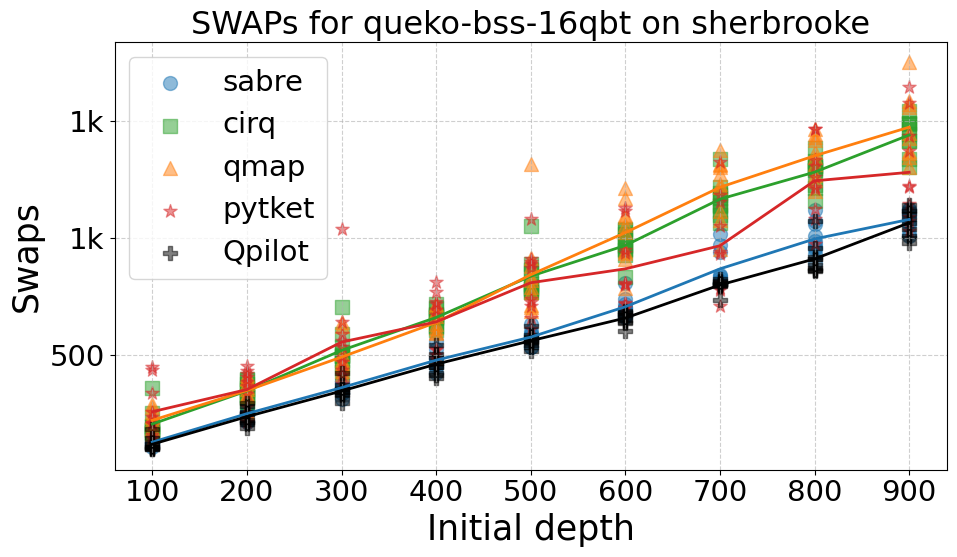

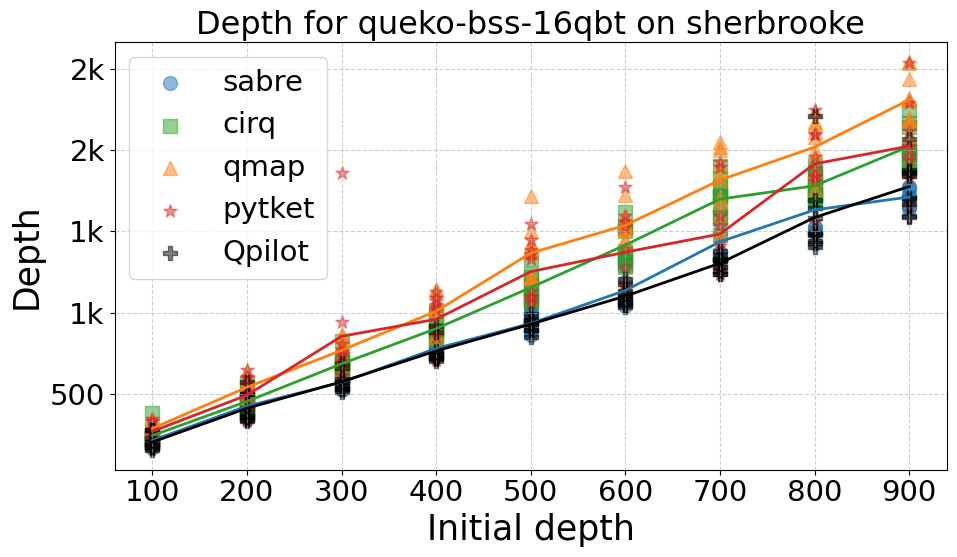

In [2]:
import os
import sys
import matplotlib.pyplot as plt

root_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
if root_dir not in sys.path:
    sys.path.append(root_dir)
    
from visualization.utils import (
    group_by_initial_depth, 
    group_by_initial_depth_baseline, 
    plot_grouped_scatter_with_noise
)
BENCHMARK = "queko-bss-16qbt"
BACKEND_NAME = "ibm_sherbrooke"

paths = {
    "sabre": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ibm_sherbrooke/queko-bss-16qbt/sabre.csv",
    "cirq": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ibm_sherbrooke/queko-bss-16qbt/cirq.csv",
    "qmap": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ibm_sherbrooke/queko-bss-16qbt/qmap.csv",
    "pytket": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ibm_sherbrooke/queko-bss-16qbt/pytket.csv",
    "Qpilot" : f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ibm_sherbrooke/queko-bss-16qbt/qpilot.csv"
}
plot_backend = "sherbrooke" if "sherbrooke" in BACKEND_NAME else "ankaa_3"
figure_idx = 6 if "sherbrooke" in BACKEND_NAME else 7
grouped_data_swaps = {}
grouped_data_depth = {}

for name, path in paths.items():
    if os.path.exists(path):
        swaps, depth = group_by_initial_depth(path)
        grouped_data_swaps[name] = swaps
        grouped_data_depth[name] = depth
    else:
        print(f"Warning: File not found for {name} at {path}")

if grouped_data_swaps:
    plot_grouped_scatter_with_noise(
        grouped_data_swaps, 
        ylabel="Swaps", 
        title=f"SWAPs for {BENCHMARK} on {plot_backend}",
        show=True,
        save=False
    )

if grouped_data_depth:
    plot_grouped_scatter_with_noise(
        grouped_data_depth, 
        ylabel="Depth", 
        title=f"Depth for {BENCHMARK} on {plot_backend}",
        show=True,
        save=False
    )

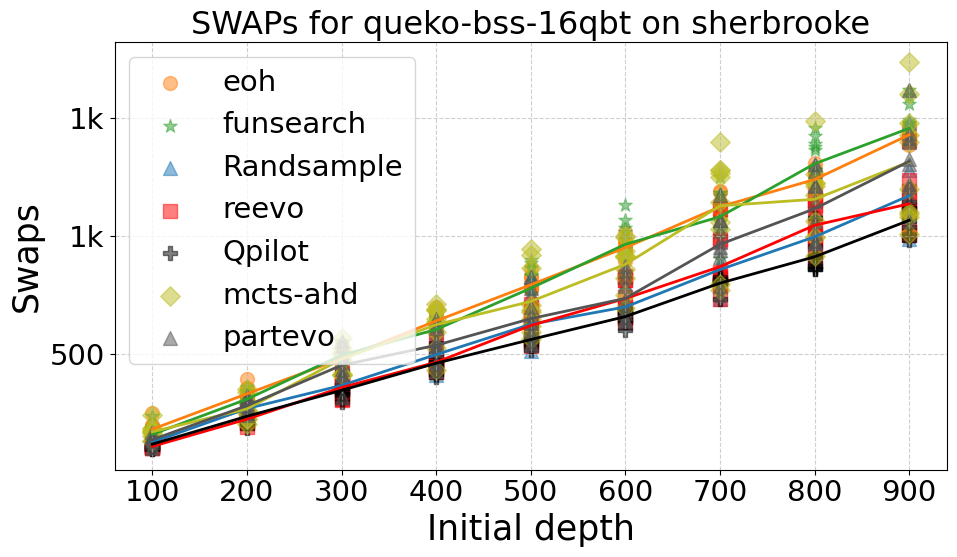

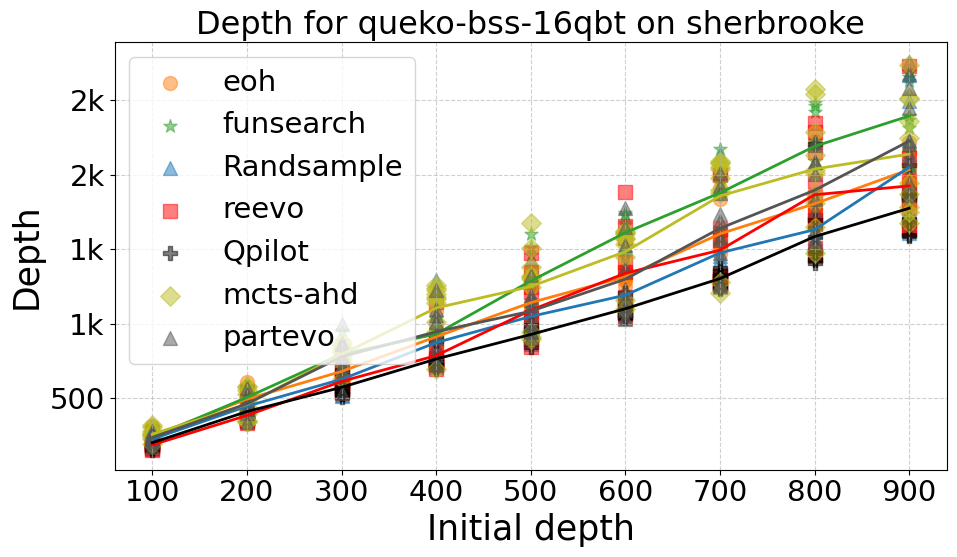

In [23]:
import os
import sys
import matplotlib.pyplot as plt

root_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
if root_dir not in sys.path:
    sys.path.append(root_dir)
    
from visualization.utils import (
    group_by_initial_depth, 
    group_by_initial_depth_baseline, 
    plot_grouped_scatter_with_noise
)
BENCHMARK = "queko-bss-16qbt"
BACKEND_NAME = "ibm_sherbrooke"

paths = {
    "eoh": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ibm_sherbrooke/queko-bss-16qbt/eoh.csv",
    "funsearch": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ibm_sherbrooke/queko-bss-16qbt/funsearch.csv",
    "Randsample": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ibm_sherbrooke/queko-bss-16qbt/Randsample.csv",
    "reevo": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ibm_sherbrooke/queko-bss-16qbt/reevo.csv",
    "Qpilot" : f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ibm_sherbrooke/queko-bss-16qbt/qpilot.csv",
    "mcts-ahd" : f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ibm_sherbrooke/queko-bss-16qbt/mcts-ahd.csv",
    "partevo" : f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ibm_sherbrooke/queko-bss-16qbt/partevo.csv"
}
plot_backend = "sherbrooke" if "sherbrooke" in BACKEND_NAME else "ankaa_3"
figure_idx = 6 if "sherbrooke" in BACKEND_NAME else 7
grouped_data_swaps = {}
grouped_data_depth = {}

for name, path in paths.items():
    if os.path.exists(path):
        swaps, depth = group_by_initial_depth(path)
        grouped_data_swaps[name] = swaps
        grouped_data_depth[name] = depth
    else:
        print(f"Warning: File not found for {name} at {path}")

if grouped_data_swaps:
    plot_grouped_scatter_with_noise(
        grouped_data_swaps, 
        ylabel="Swaps", 
        title=f"SWAPs for {BENCHMARK} on {plot_backend}",
        show=True,
        save=False
    )

if grouped_data_depth:
    plot_grouped_scatter_with_noise(
        grouped_data_depth, 
        ylabel="Depth", 
        title=f"Depth for {BENCHMARK} on {plot_backend}",
        show=True,
        save=False
    )

## Benchmark Results: queko16qbt

### Raw Performance Metrics


| Source File      | Swap Count | Final Depth |
| :--------------- | :--------- | :---------- |
| `qpilot.csv`     | 591.155556 | 965.155556  |
| `cirq.csv`       | 824.711111 | 1150.033333 |
| `qmap.csv`       | 845.011111 | 1293.944444 |
| `pytket.csv`     | 774.811111 | 1179.688889 |
| `eoh.csv`        | 795.444444 | 1137.533333 |
| `funsearch.csv`  | 793.777778 | 1314.900000 |
| `Reevo.csv`      | 617.166667 | 1076.633333 |
| `Randsample.csv` | 622.333333 | 1063.833333 |
| `mcts-ahd.csv`   | 747.844444 | 1265.511111 |
| `hill_climb.csv` | 780.888889 | 1327.255556 |
| `sabre.csv`      | 604.111111 | 981.522222  |
| `partevo.csv`    | 686.677778 | 1174.700000 |



### Improvement Percentages
| Method     | Swap Improvement (%) | Depth Improvement (%) |
| :--------- | :------------------- | :-------------------- |
| **cirq**   | 28.32                | 16.08                 |
| **pytket** | 23.70                | 18.19                 |
| **sabre**  | 2.14                 | 1.67                  |
| **qmap**   | 30.04                | 25.41                 |



### Improvement Percentages
| Method         | Swap Improvement (%) | Depth Improvement (%) |
| :------------- | :------------------- | :-------------------- |
| **eoh**        | 25.68                | 15.15                 |
| **funsearch**  | 25.53                | 26.60                 |
| **Reevo**      | 4.21                 | 10.35                 |
| **Randsample** | 5.01                 | 9.28                  |
| **mcts-ahd**   | 20.95                | 23.73                 |
| **hill_climb** | 24.30                | 27.28                 |
| **partevo**    | 13.91                | 17.84                 |




### plots queko-54qbt

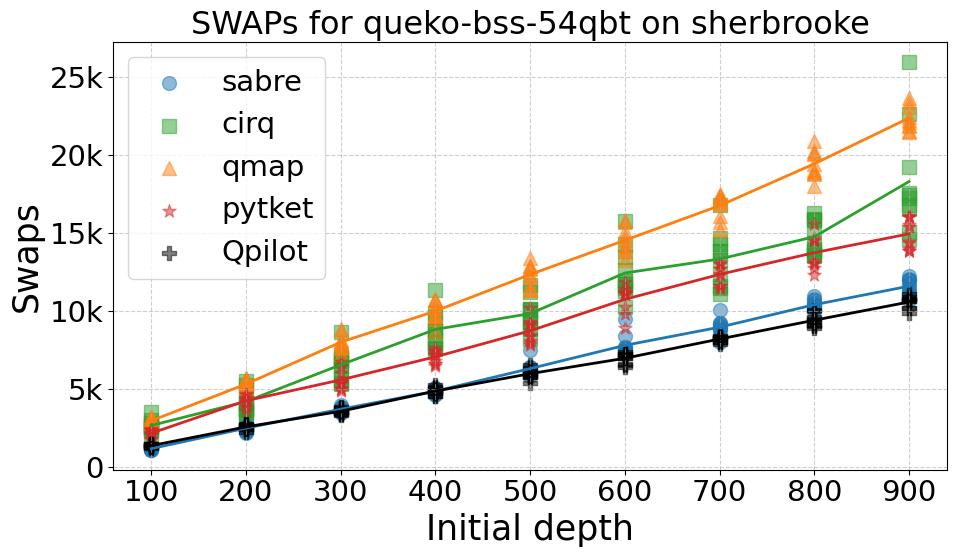

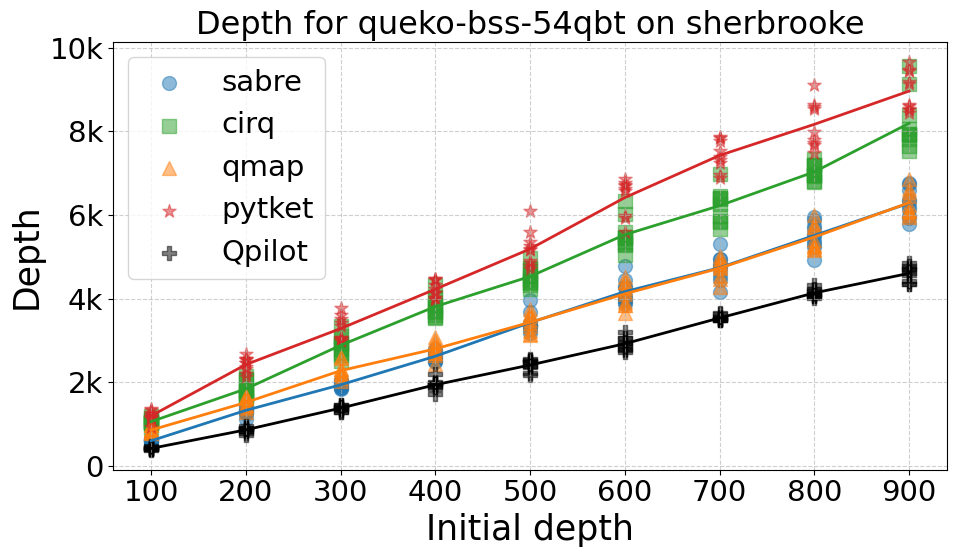

In [3]:
import os
import sys
import matplotlib.pyplot as plt

root_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
if root_dir not in sys.path:
    sys.path.append(root_dir)
    
from visualization.utils import (
    group_by_initial_depth, 
    group_by_initial_depth_baseline, 
    plot_grouped_scatter_with_noise
)
BENCHMARK = "queko-bss-54qbt"
BACKEND_NAME = "ibm_sherbrooke"

paths = {
    "sabre": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ibm_sherbrooke/queko-bss-54qbt/sabre.csv",
    "cirq": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ibm_sherbrooke/queko-bss-54qbt/cirq.csv",
    "qmap": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ibm_sherbrooke/queko-bss-54qbt/qmap.csv",
    "pytket": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ibm_sherbrooke/queko-bss-54qbt/pytket.csv",
    "Qpilot" : f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ibm_sherbrooke/queko-bss-54qbt/qpilot.csv"
}
plot_backend = "sherbrooke" if "sherbrooke" in BACKEND_NAME else "ankaa_3"
figure_idx = 6 if "sherbrooke" in BACKEND_NAME else 7
grouped_data_swaps = {}
grouped_data_depth = {}

for name, path in paths.items():
    if os.path.exists(path):
        swaps, depth = group_by_initial_depth(path)
        grouped_data_swaps[name] = swaps
        grouped_data_depth[name] = depth
    else:
        print(f"Warning: File not found for {name} at {path}")

if grouped_data_swaps:
    plot_grouped_scatter_with_noise(
        grouped_data_swaps, 
        ylabel="Swaps", 
        title=f"SWAPs for {BENCHMARK} on {plot_backend}",
        show=True,
        save=False
    )

if grouped_data_depth:
    plot_grouped_scatter_with_noise(
        grouped_data_depth, 
        ylabel="Depth", 
        title=f"Depth for {BENCHMARK} on {plot_backend}",
        show=True,
        save=False
    )

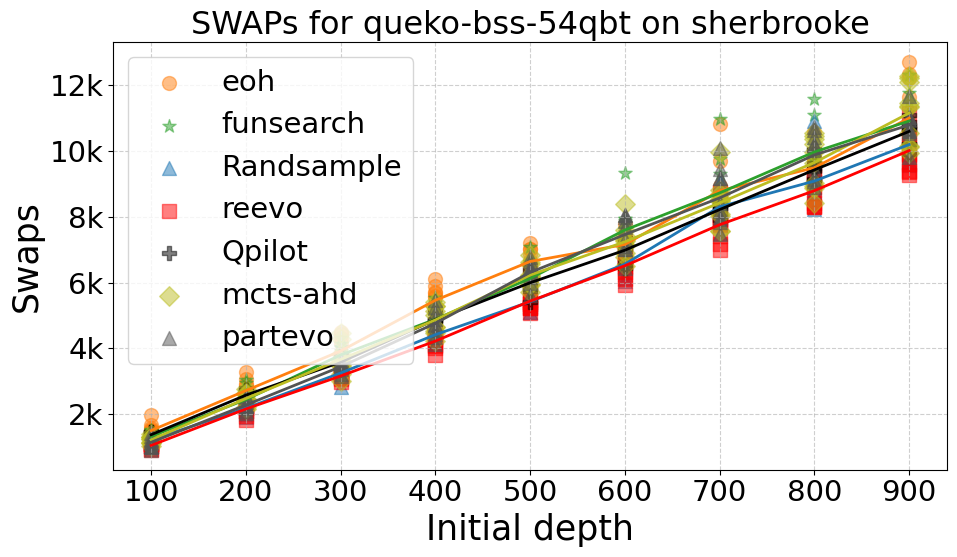

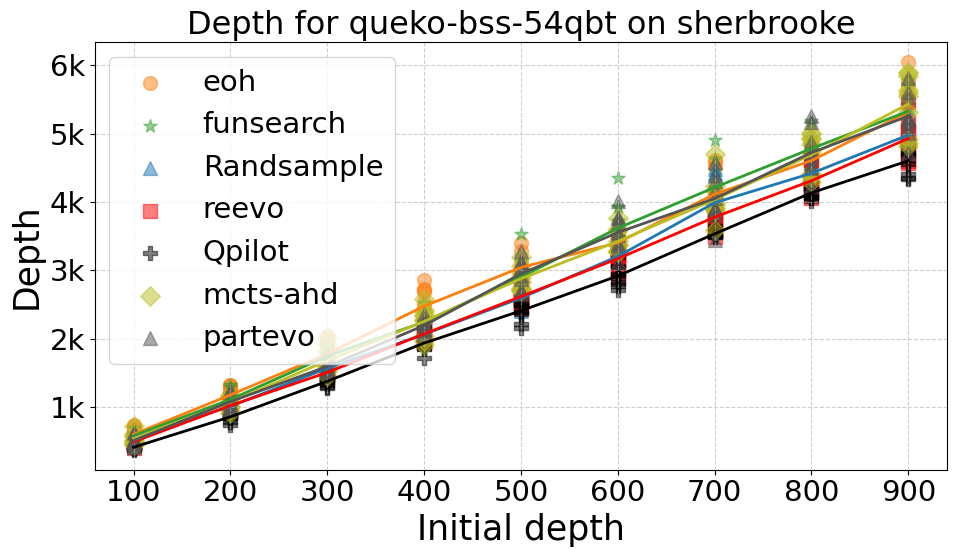

In [24]:
import os
import sys
import matplotlib.pyplot as plt

root_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
if root_dir not in sys.path:
    sys.path.append(root_dir)
    
from visualization.utils import (
    group_by_initial_depth, 
    group_by_initial_depth_baseline, 
    plot_grouped_scatter_with_noise
)
BENCHMARK = "queko-bss-54qbt"
BACKEND_NAME = "ibm_sherbrooke"

paths = {
    "eoh": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ibm_sherbrooke/queko-bss-54qbt/eoh.csv",
    "funsearch": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ibm_sherbrooke/queko-bss-54qbt/funsearch.csv",
    "Randsample": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ibm_sherbrooke/queko-bss-54qbt/Randsample.csv",
    "reevo": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ibm_sherbrooke/queko-bss-54qbt/reevo.csv",
    "Qpilot" : f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ibm_sherbrooke/queko-bss-54qbt/qpilot.csv",
    "mcts-ahd" : f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ibm_sherbrooke/queko-bss-54qbt/mcts-ahd.csv",
    "partevo" : f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ibm_sherbrooke/queko-bss-54qbt/partevo.csv"
}
plot_backend = "sherbrooke" if "sherbrooke" in BACKEND_NAME else "ankaa_3"
figure_idx = 6 if "sherbrooke" in BACKEND_NAME else 7
grouped_data_swaps = {}
grouped_data_depth = {}

for name, path in paths.items():
    if os.path.exists(path):
        swaps, depth = group_by_initial_depth(path)
        grouped_data_swaps[name] = swaps
        grouped_data_depth[name] = depth
    else:
        print(f"Warning: File not found for {name} at {path}")

if grouped_data_swaps:
    plot_grouped_scatter_with_noise(
        grouped_data_swaps, 
        ylabel="Swaps", 
        title=f"SWAPs for {BENCHMARK} on {plot_backend}",
        show=True,
        save=False
    )

if grouped_data_depth:
    plot_grouped_scatter_with_noise(
        grouped_data_depth, 
        ylabel="Depth", 
        title=f"Depth for {BENCHMARK} on {plot_backend}",
        show=True,
        save=False
    )

## Benchmark Results: queko54qbt

### Raw Performance Metrics
| Source File      | Swap Count   | Final Depth |
| :--------------- | :----------- | :---------- |
| `qpilot.csv`     | 5360.277778  | 2485.900000 |
| `cirq.csv`       | 10111.922222 | 4565.433333 |
| `qmap.csv`       | 12426.188889 | 3496.344444 |
| `eoh.csv`        | 6297.288889  | 2946.222222 |
| `funsearch.csv`  | 6197.055556  | 2947.111111 |
| `Reevo.csv`      | 5455.766667  | 2654.955556 |
| `Randsample.csv` | 5624.777778  | 2708.966667 |
| `mcts-ahd.csv`   | 6100.411111  | 2889.400000 |
| `hill_climb.csv` | 6317.877778  | 2994.611111 |
| `sabre.csv`      | 6378.322222  | 3398.655556 |
| `partevo.csv`    | 6070.411111  | 2878.488889 |



### Improvement Percentages
| Method    | Swap Improvement (%) | Depth Improvement (%) |
| :-------- | :------------------- | :-------------------- |
| **cirq**  | 46.99                | 45.55                 |
| **qmap**  | 56.86                | 28.90                 |
| **sabre** | 15.96                | 26.86                 |

### Improvement Percentages
| Method         | Swap Improvement (%) | Depth Improvement (%) |
| :------------- | :------------------- | :-------------------- |
| **eoh**        | 14.88                | 15.62                 |
| **funsearch**  | 13.50                | 15.65                 |
| **Reevo**      | 1.75                 | 6.37                  |
| **Randsample** | 4.70                 | 8.23                  |
| **mcts-ahd**   | 12.13                | 13.96                 |
| **hill_climb** | 15.16                | 16.99                 |
| **partevo**    | 11.70                | 13.64                 |


### plots queko-81qbt

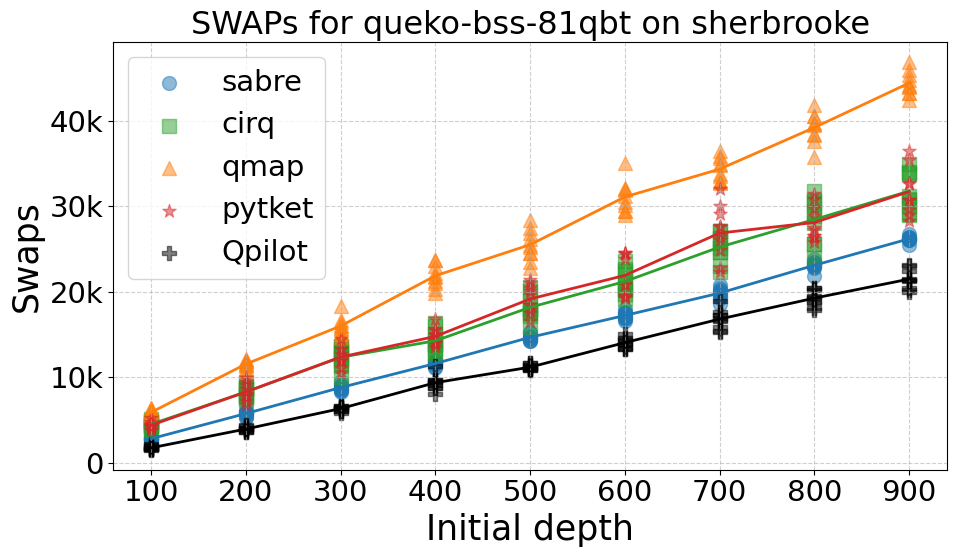

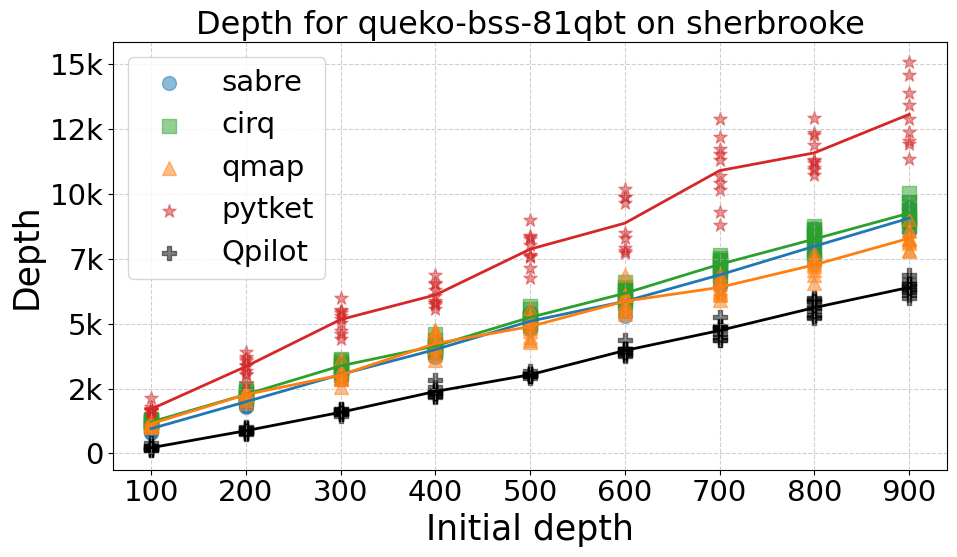

In [25]:
import os
import sys
import matplotlib.pyplot as plt

root_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
if root_dir not in sys.path:
    sys.path.append(root_dir)
    
from visualization.utils import (
    group_by_initial_depth, 
    group_by_initial_depth_baseline, 
    plot_grouped_scatter_with_noise
)
BENCHMARK = "queko-bss-81qbt"
BACKEND_NAME = "ibm_sherbrooke"

paths = {
    "sabre": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ibm_sherbrooke/queko-bss-81qbt/sabre.csv",
    "cirq": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ibm_sherbrooke/queko-bss-81qbt/cirq.csv",
    "qmap": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ibm_sherbrooke/queko-bss-81qbt/qmap.csv",
    "pytket": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ibm_sherbrooke/queko-bss-81qbt/pytket.csv",
    "Qpilot" : f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ibm_sherbrooke/queko-bss-81qbt/qpilot.csv"
}
plot_backend = "sherbrooke" if "sherbrooke" in BACKEND_NAME else "ankaa_3"
figure_idx = 6 if "sherbrooke" in BACKEND_NAME else 7
grouped_data_swaps = {}
grouped_data_depth = {}

for name, path in paths.items():
    if os.path.exists(path):
        swaps, depth = group_by_initial_depth(path)
        grouped_data_swaps[name] = swaps
        grouped_data_depth[name] = depth
    else:
        print(f"Warning: File not found for {name} at {path}")

if grouped_data_swaps:
    plot_grouped_scatter_with_noise(
        grouped_data_swaps, 
        ylabel="Swaps", 
        title=f"SWAPs for {BENCHMARK} on {plot_backend}",
        show=True,
        save=False
    )

if grouped_data_depth:
    plot_grouped_scatter_with_noise(
        grouped_data_depth, 
        ylabel="Depth", 
        title=f"Depth for {BENCHMARK} on {plot_backend}",
        show=True,
        save=False
    )

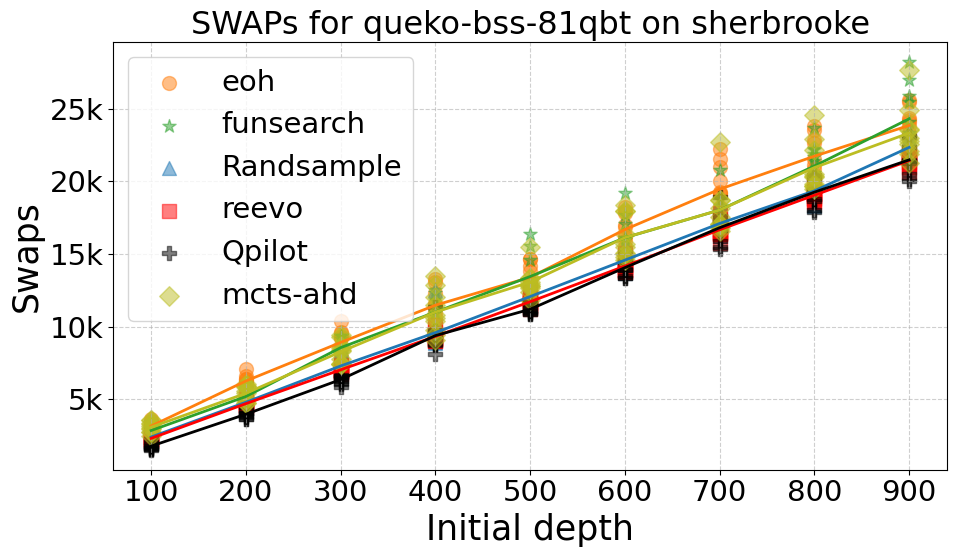

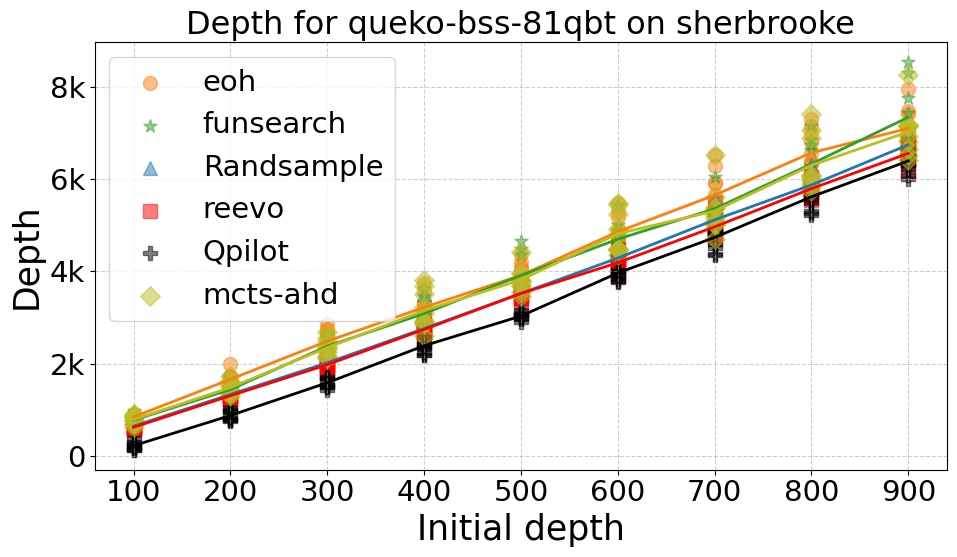

In [26]:
import os
import sys
import matplotlib.pyplot as plt

root_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
if root_dir not in sys.path:
    sys.path.append(root_dir)
    
from visualization.utils import (
    group_by_initial_depth, 
    group_by_initial_depth_baseline, 
    plot_grouped_scatter_with_noise
)
BENCHMARK = "queko-bss-81qbt"
BACKEND_NAME = "ibm_sherbrooke"

paths = {
    "eoh": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ibm_sherbrooke/queko-bss-81qbt/eoh.csv",
    "funsearch": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ibm_sherbrooke/queko-bss-81qbt/funsearch.csv",
    "Randsample": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ibm_sherbrooke/queko-bss-81qbt/Randsample.csv",
    "reevo": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ibm_sherbrooke/queko-bss-81qbt/reevo.csv",
    "Qpilot" : f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ibm_sherbrooke/queko-bss-81qbt/qpilot.csv",
    "mcts-ahd" : f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ibm_sherbrooke/queko-bss-81qbt/mcts-ahd.csv"
}
plot_backend = "sherbrooke" if "sherbrooke" in BACKEND_NAME else "ankaa_3"
figure_idx = 6 if "sherbrooke" in BACKEND_NAME else 7
grouped_data_swaps = {}
grouped_data_depth = {}

for name, path in paths.items():
    if os.path.exists(path):
        swaps, depth = group_by_initial_depth(path)
        grouped_data_swaps[name] = swaps
        grouped_data_depth[name] = depth
    else:
        print(f"Warning: File not found for {name} at {path}")

if grouped_data_swaps:
    plot_grouped_scatter_with_noise(
        grouped_data_swaps, 
        ylabel="Swaps", 
        title=f"SWAPs for {BENCHMARK} on {plot_backend}",
        show=True,
        save=False
    )

if grouped_data_depth:
    plot_grouped_scatter_with_noise(
        grouped_data_depth, 
        ylabel="Depth", 
        title=f"Depth for {BENCHMARK} on {plot_backend}",
        show=True,
        save=False
    )

## Benchmark Results: queko81qbt

### Raw Performance Metrics
| Source File      | Swap Count   | Final Depth |
| :--------------- | :----------- | :---------- |
| `qpilot.csv`     | 11597.500000 | 3202.200000 |
| `cirq.csv`       | 18258.522222 | 5244.800000 |
| `qmap.csv`       | 25539.500000 | 4818.633333 |
| `pytket.csv`     | 18443.306818 | 7544.625000 |
| `eoh.csv`        | 13889.877778 | 4034.800000 |
| `funsearch.csv`  | 13403.833333 | 3924.344444 |
| `Reevo.csv`      | 11831.377778 | 3519.511111 |
| `Randsample.csv` | 12177.377778 | 3589.288889 |
| `mcts-ahd.csv`   | 13260.422222 | 3893.244444 |
| `hill_climb.csv` | 13632.055556 | 3965.888889 |
| `sabre.csv`      | 14463.044444 | 4984.077778 |
| `partevo.csv`    | 12981.766667 | 3776.044444 |



### Improvement Percentages
| Method     | Swap Improvement (%) | Depth Improvement (%) |
| :--------- | :------------------- | :-------------------- |
| **cirq**   | 36.48                | 38.95                 |
| **pytket** | —                    | —                     |
| **sabre**  | 19.81                | 35.75                 |
| **qmap**   | 54.59                | 33.55                 |

### Improvement Percentages
| Method         | Swap Improvement (%) | Depth Improvement (%) |
| :------------- | :------------------- | :-------------------- |
| **eoh**        | 16.50                | 20.64                 |
| **funsearch**  | 13.48                | 18.40                 |
| **Reevo**      | 1.98                 | 9.02                  |
| **Randsample** | 4.76                 | 10.78                 |
| **mcts-ahd**   | 12.54                | 17.75                 |
| **hill_climb** | 14.92                | 19.26                 |
| **partevo**    | 10.66                | 15.20                 |

